# Foot Track Data Visualization

Interactive plotting of foot track logging data with timesteps.

**Before running this notebook:**
1. Run `foot_track_plot.py` to collect data
2. Press 'a' and 'd' keys to log foot steps
3. Exit with Ctrl+C
4. Update the `csv_file` path below to point to your log file

## Setup: Install and Import Dependencies

In [15]:
# Install required packages if needed
import subprocess
import sys

packages = ['pandas', 'numpy', 'matplotlib', 'scipy']
for package in packages:
    try:
        __import__(package)
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

print("All dependencies installed!")

All dependencies installed!


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.spatial.transform import Rotation as R
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

print("✓ All imports successful!")

✓ All imports successful!


## Step 1: Load Your Data

In [17]:
# Fix Python path to find CSV files using relative paths
from pathlib import Path
import os

# Get the directory where this notebook is located
notebook_dir = Path.cwd()
print(f"Current working directory: {notebook_dir}")

# Try to find foot_track_logs relative to current directory or parent directories
csv_dir = None
for potential_dir in [
    Path('./foot_track_logs'),
    Path('../foot_track_logs'),
    Path('../../foot_track_logs'),
    Path('../../../foot_track_logs'),
]:
    potential_dir = potential_dir.resolve()  # Convert to absolute for checking
    if potential_dir.exists():
        csv_dir = potential_dir
        print(f"✓ Found foot_track_logs at: {csv_dir}")
        break

if not csv_dir:
    print("ERROR: Could not find foot_track_logs directory")
    print("Please run this notebook from the IsaacLab root directory:")
    print("  cd /home/thong/IsaacLab")
    print("  jupyter notebook sim2real/rl_policy/foot_track/plot_foot_track_data.ipynb")
    raise FileNotFoundError("foot_track_logs directory not found")

# Find the latest CSV file
csv_files = list(csv_dir.glob('foot_track_data_20251216_134257.csv'))
if not csv_files:
    print(f"ERROR: No CSV files found in {csv_dir}")
    raise FileNotFoundError(f"No foot track CSV files found in {csv_dir}")

csv_file = sorted(csv_files)[-1]  # Get latest
print(f"✓ Found latest log file: {csv_file}")

# Load the data
df = pd.read_csv(csv_file)
print(f"✓ Loaded {len(df)} rows from {csv_file}")
print(f"\nColumns: {len(df.columns)}")
print(f"Data shape: {df.shape}")

Current working directory: /home/zimengchai/Documents/IsaacLab/sim2real/rl_policy/foot_track
✓ Found foot_track_logs at: /home/zimengchai/Documents/IsaacLab/foot_track_logs
✓ Found latest log file: /home/zimengchai/Documents/IsaacLab/foot_track_logs/foot_track_data_20251216_134257.csv
✓ Loaded 1126 rows from /home/zimengchai/Documents/IsaacLab/foot_track_logs/foot_track_data_20251216_134257.csv

Columns: 86
Data shape: (1126, 86)


## Step 2: Data Overview & Statistics

In [ ]:
print("="*70)
print("DATA STATISTICS")
print("="*70)
print(f"\nTotal timesteps logged: {len(df)}")
print(f"Timestep range: {df['timestep'].min()} to {df['timestep'].max()}")

# ===== SET START AND END TIMESTEPS FOR PLOTTING =====
# Change these values to plot only a specific range
START_TIMESTEP = 1000            # First timestep to include (default: 1)
END_TIMESTEP = 1500
# START_TIMESTEP = 1           # First timestep to include (default: 1)
# END_TIMESTEP = df['timestep'].max()  # Last timestep to include (default: max)
# ====================================================

# Filter data based on timestep range
df_plot = df[(df['timestep'] >= START_TIMESTEP) & (df['timestep'] <= END_TIMESTEP)].copy()
print(f"\nPlotting timestep range: {START_TIMESTEP} to {END_TIMESTEP}")
print(f"Rows to plot: {len(df_plot)}")

print("\nKeyboard Commands:")
kb_counts = df_plot['keyboard_key'].value_counts()
for key, count in kb_counts.items():
    foot = "Left Foot" if key == 'a' else "Right Foot"
    print(f"  '{key}' ({foot}): {count} times")

print("\nFoot Position Ranges (meters):")
print(f"  Left Foot X:  {df_plot['left_foot_xpos_x'].min():.4f} to {df_plot['left_foot_xpos_x'].max():.4f}")
print(f"  Left Foot Y:  {df_plot['left_foot_xpos_y'].min():.4f} to {df_plot['left_foot_xpos_y'].max():.4f}")
print(f"  Left Foot Z:  {df_plot['left_foot_xpos_z'].min():.4f} to {df_plot['left_foot_xpos_z'].max():.4f}")
print(f"  Right Foot X: {df_plot['right_foot_xpos_x'].min():.4f} to {df_plot['right_foot_xpos_x'].max():.4f}")
print(f"  Right Foot Y: {df_plot['right_foot_xpos_y'].min():.4f} to {df_plot['right_foot_xpos_y'].max():.4f}")
print(f"  Right Foot Z: {df_plot['right_foot_xpos_z'].min():.4f} to {df_plot['right_foot_xpos_z'].max():.4f}")

print("\nCommand Parameters:")
print(f"  Countdown range: {df_plot['command_countdown_0'].min():.4f} to {df_plot['command_countdown_0'].max():.4f}")
print(f"  STSW Pose X range: {df_plot['command_stsw_pose_0'].min():.4f} to {df_plot['command_stsw_pose_0'].max():.4f}")
print(f"  STSW Pose Y range: {df_plot['command_stsw_pose_1'].min():.4f} to {df_plot['command_stsw_pose_1'].max():.4f}")

print("="*70)

# Show first few rows
print("\nFirst 5 rows of filtered data:")
df_plot.head()

DATA STATISTICS

Total timesteps logged: 1126
Timestep range: 1 to 1126

Plotting timestep range: 0 to 100
Rows to plot: 100

Keyboard Commands:

Foot Position Ranges (meters):
  Left Foot X:  0.0648 to 0.0723
  Left Foot Y:  0.1061 to 0.1061
  Left Foot Z:  0.0258 to 0.0298
  Right Foot X: 0.0648 to 0.0724
  Right Foot Y: -0.1062 to -0.1061
  Right Foot Z: 0.0258 to 0.0298

Command Parameters:
  Countdown range: 0.0000 to 0.0000
  STSW Pose X range: 0.0000 to 0.0000
  STSW Pose Y range: -0.2000 to -0.2000

First 5 rows of filtered data:


,timestep,keyboard_key,command_foot_indicator,command_countdown_0,command_stsw_pose_0,command_stsw_pose_1,command_stsw_pose_2,command_stsw_pose_3,action_0,action_1,...,right_foot_xmat_8,right_foot_vel_x,right_foot_vel_y,right_foot_vel_z,swing_stance_delta_x,swing_stance_delta_y,swing_stance_delta_z,com_x,com_y,com_z
0,1,NaN,0.0,0.0,0.0,-0.2,0.0,0.0,0.019486,-0.019585,...,0.999706,13.999980,-2.123184e+01,5.950161,0.000127,-0.212299,-0.000043,0.130988,-0.000155,0.576787
1,2,NaN,0.0,0.0,0.0,-0.2,0.0,0.0,0.035540,-0.019156,...,0.999705,-0.001214,6.930339e-08,-0.000265,0.000127,-0.212299,-0.000043,0.130988,-0.000155,0.576787
2,3,NaN,0.0,0.0,0.0,-0.2,0.0,0.0,0.068094,0.005664,...,0.999707,0.003720,1.197791e-05,0.000288,0.000127,-0.212299,-0.000043,0.130990,-0.000155,0.576786
3,4,NaN,0.0,0.0,0.0,-0.2,0.0,0.0,0.108058,0.047236,...,0.999708,0.005973,3.800818e-05,0.000069,0.000126,-0.212298,-0.000043,0.130993,-0.000155,0.576785
4,5,NaN,0.0,0.0,0.0,-0.2,0.0,0.0,0.124408,0.065728,...,0.999710,0.006593,4.279305e-05,0.000088,0.000126,-0.212297,-0.000043,0.130996,-0.000155,0.576783


## Plot 1: Foot Positions Over Time

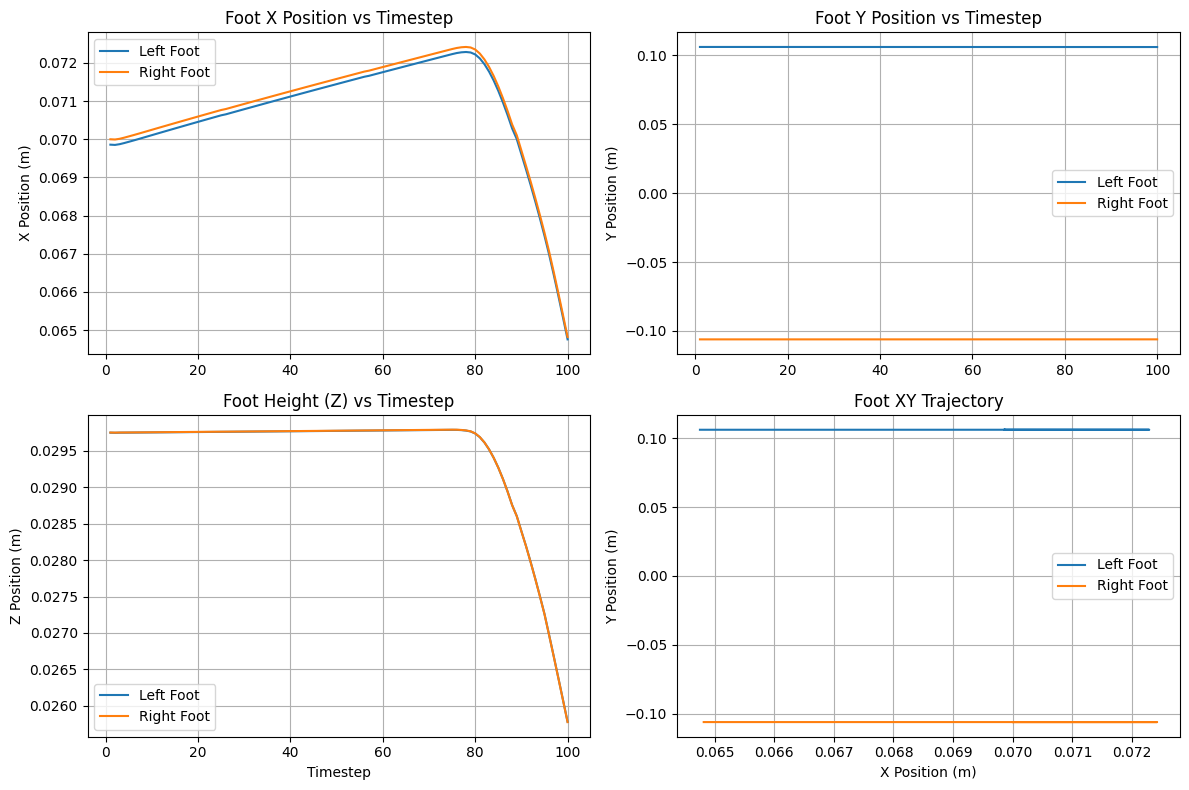

✓ Foot positions plot generated!


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

timesteps = df_plot['timestep'].values

# Left foot X
axes[0, 0].plot(timesteps, df_plot['left_foot_xpos_x'], label='Left Foot')
axes[0, 0].plot(timesteps, df_plot['right_foot_xpos_x'], label='Right Foot')
axes[0, 0].set_ylabel('X Position (m)')
axes[0, 0].set_title('Foot X Position vs Timestep')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Left foot Y
axes[0, 1].plot(timesteps, df_plot['left_foot_xpos_y'], label='Left Foot')
axes[0, 1].plot(timesteps, df_plot['right_foot_xpos_y'], label='Right Foot')
axes[0, 1].set_ylabel('Y Position (m)')
axes[0, 1].set_title('Foot Y Position vs Timestep')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Foot Z (height)
axes[1, 0].plot(timesteps, df_plot['left_foot_xpos_z'], label='Left Foot')
axes[1, 0].plot(timesteps, df_plot['right_foot_xpos_z'], label='Right Foot')
axes[1, 0].set_ylabel('Z Position (m)')
axes[1, 0].set_xlabel('Timestep')
axes[1, 0].set_title('Foot Height (Z) vs Timestep')
axes[1, 0].legend()
axes[1, 0].grid(True)

# XY Trajectory
axes[1, 1].plot(df_plot['left_foot_xpos_x'], df_plot['left_foot_xpos_y'], label='Left Foot')
axes[1, 1].plot(df_plot['right_foot_xpos_x'], df_plot['right_foot_xpos_y'], label='Right Foot')
axes[1, 1].set_xlabel('X Position (m)')
axes[1, 1].set_ylabel('Y Position (m)')
axes[1, 1].set_title('Foot XY Trajectory')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

print("✓ Foot positions plot generated!")

## Plot 3: Command Parameters

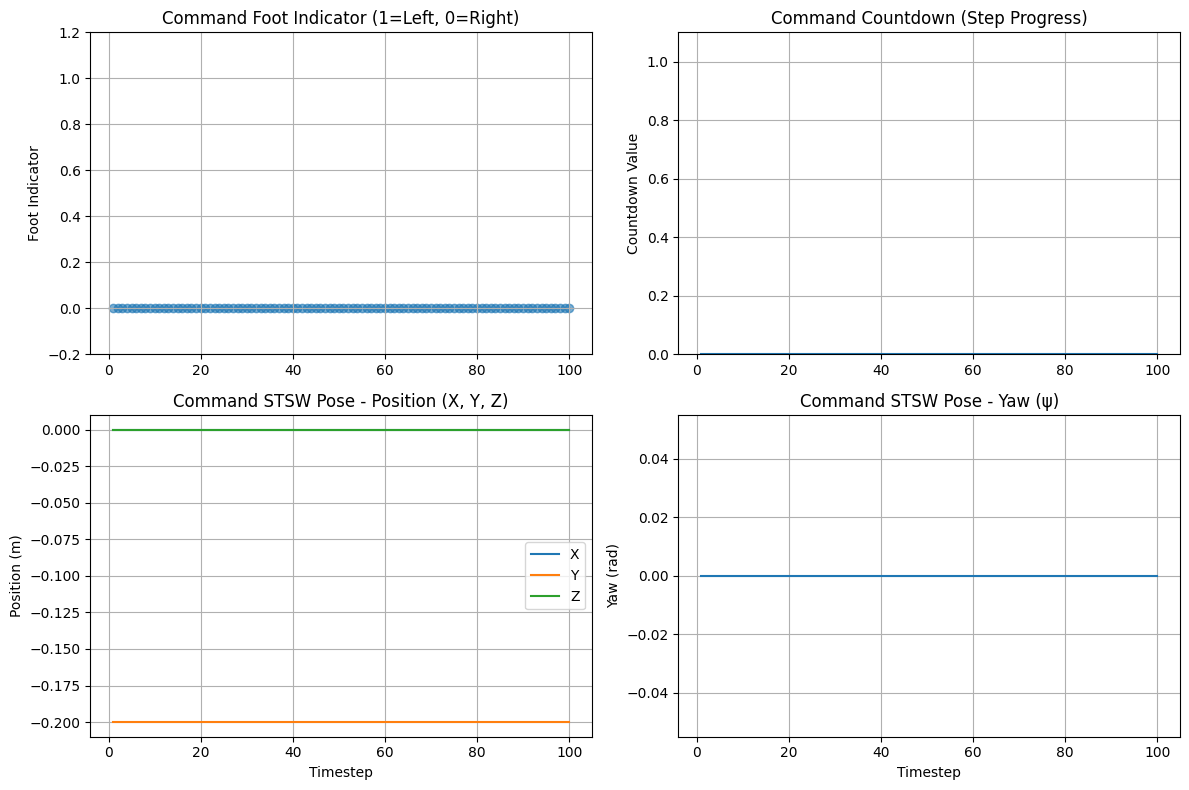

✓ Command parameters plot generated!


In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

timesteps = df_plot['timestep'].values

# Command foot indicator
ax = axes[0, 0]
ax.scatter(timesteps, df_plot['command_foot_indicator'], alpha=0.6)
ax.set_ylabel('Foot Indicator')
ax.set_title('Command Foot Indicator (1=Left, 0=Right)')
ax.set_ylim([-0.2, 1.2])
ax.grid(True)

# Command countdown
ax = axes[0, 1]
ax.plot(timesteps, df_plot['command_countdown_0'])
ax.set_ylabel('Countdown Value')
ax.set_title('Command Countdown (Step Progress)')
ax.set_ylim([0, 1.1])
ax.grid(True)

# Command STSW pose - position
ax = axes[1, 0]
ax.plot(timesteps, df_plot['command_stsw_pose_0'], label='X')
ax.plot(timesteps, df_plot['command_stsw_pose_1'], label='Y')
ax.plot(timesteps, df_plot['command_stsw_pose_2'], label='Z')
ax.set_ylabel('Position (m)')
ax.set_xlabel('Timestep')
ax.set_title('Command STSW Pose - Position (X, Y, Z)')
ax.legend()
ax.grid(True)

# Command STSW pose - yaw
ax = axes[1, 1]
ax.plot(timesteps, df_plot['command_stsw_pose_3'])
ax.set_ylabel('Yaw (rad)')
ax.set_xlabel('Timestep')
ax.set_title('Command STSW Pose - Yaw (ψ)')
ax.grid(True)

plt.tight_layout()
plt.show()

print("✓ Command parameters plot generated!")

## Plot 4: Policy Action Outputs (All 12 DOF)

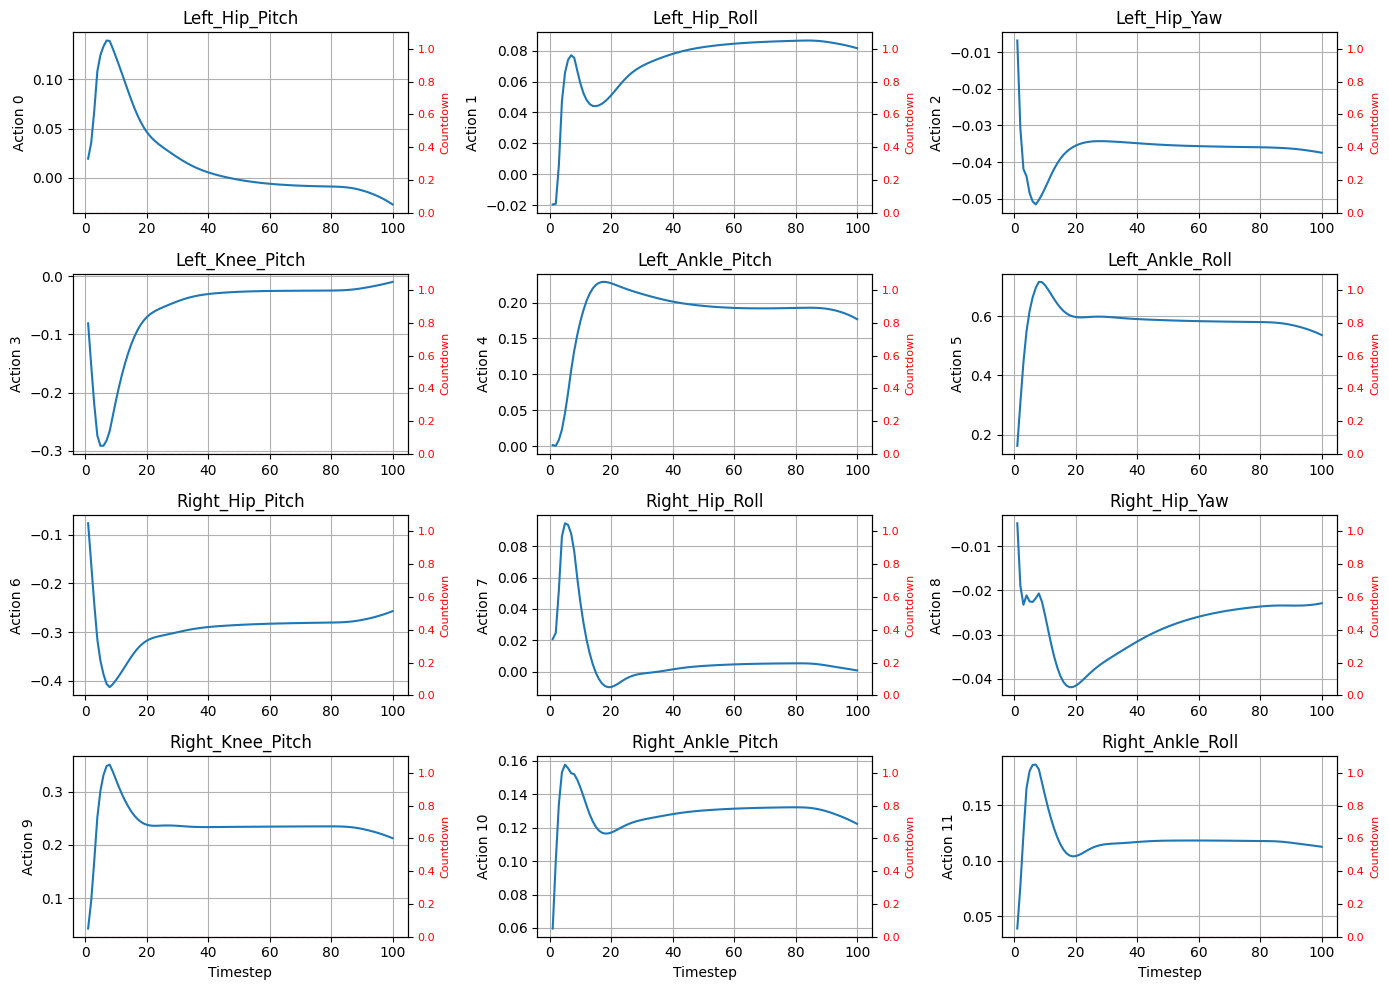

✓ Policy actions plot generated with command countdown overlay!


In [21]:
fig, axes = plt.subplots(4, 3, figsize=(14, 10))

timesteps = df_plot['timestep'].values
action_cols = [f'action_{i}' for i in range(12)]

# DOF names in order
dof_names = [
    "Left_Hip_Pitch",
    "Left_Hip_Roll",
    "Left_Hip_Yaw",
    "Left_Knee_Pitch",
    "Left_Ankle_Pitch",
    "Left_Ankle_Roll",
    "Right_Hip_Pitch",
    "Right_Hip_Roll",
    "Right_Hip_Yaw",
    "Right_Knee_Pitch",
    "Right_Ankle_Pitch",
    "Right_Ankle_Roll",
]

for i, col in enumerate(action_cols):
    ax = axes[i // 3, i % 3]
    ax.plot(timesteps, df_plot[col])
    ax.set_ylabel(f'Action {i}')
    ax.set_title(f'{dof_names[i]}')
    ax.grid(True)
    
    # Add command countdown as overlay on secondary axis
    ax2 = ax.twinx()
    ax2.plot(timesteps, df_plot['command_countdown_0'], color='red', alpha=0.3, linewidth=1, linestyle='--', label='Countdown')
    ax2.set_ylabel('Countdown', color='red', fontsize=8)
    ax2.tick_params(axis='y', labelcolor='red', labelsize=8)
    ax2.set_ylim([0, 1.1])

axes[3, 0].set_xlabel('Timestep')
axes[3, 1].set_xlabel('Timestep')
axes[3, 2].set_xlabel('Timestep')

plt.tight_layout()
plt.show()

print("✓ Policy actions plot generated with command countdown overlay!")

## Plot 6: Swing-Stance Position Difference vs Command Foot

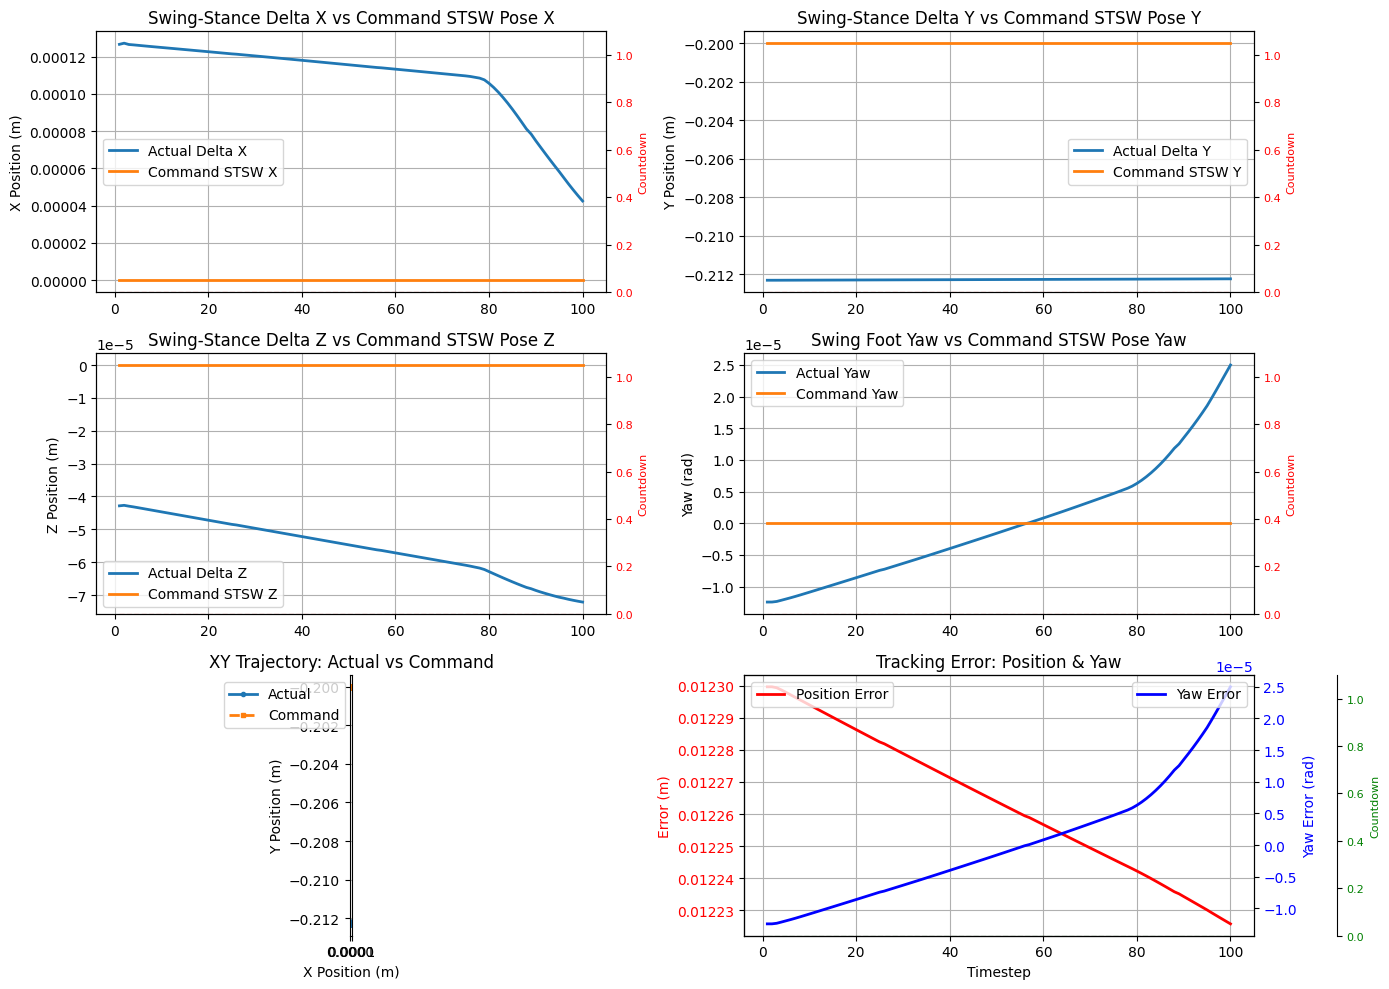

✓ Swing-stance vs command STSW pose comparison plot generated with countdown overlays!

Tracking Error Stats:
  X Error: 0.0001 ± 0.0000 m
  Y Error: -0.0123 ± 0.0000 m
  Z Error: -0.0001 ± 0.0000 m
  Yaw Error: -0.0000 ± 0.0000 rad
  Position Magnitude Error: 0.0123 ± 0.0000 m
  Max Position Error: 0.0123 m
  Max Yaw Error: 0.0000 rad


In [22]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

timesteps = df_plot['timestep'].values

# Extract yaw from rotation matrices for both feet
def rotation_matrices_to_yaw(matrices_data):
    """Extract yaw angle from 3x3 rotation matrices."""
    yaw_angles = []
    for i in range(len(matrices_data)):
        mat = matrices_data[i].reshape(3, 3)
        try:
            r = R.from_matrix(mat)
            euler = r.as_euler('xyz')
            yaw = euler[2]  # Yaw is the third angle
            yaw_angles.append(yaw)
        except:
            yaw_angles.append(0)
    return np.array(yaw_angles)

# Get actual yaw angles from foot rotations
left_yaw = rotation_matrices_to_yaw(df_plot[[f'left_foot_xmat_{i}' for i in range(9)]].values)
right_yaw = rotation_matrices_to_yaw(df_plot[[f'right_foot_xmat_{i}' for i in range(9)]].values)

# Determine actual yaw based on stance foot
actual_yaw = np.where(df_plot['command_foot_indicator'] == 0, right_yaw, left_yaw)

# Swing-Stance Delta X vs Command STSW Pose X
ax = axes[0, 0]
ax.plot(timesteps, df_plot['swing_stance_delta_x'], label='Actual Delta X', linewidth=2)
ax.plot(timesteps, df_plot['command_stsw_pose_0'], label='Command STSW X', linewidth=2)
ax.set_ylabel('X Position (m)')
ax.set_title('Swing-Stance Delta X vs Command STSW Pose X')
ax.legend()
ax.grid(True)
# Add countdown overlay
ax2 = ax.twinx()
ax2.plot(timesteps, df_plot['command_countdown_0'], color='red', alpha=0.3, linewidth=1, linestyle='--', label='Countdown')
ax2.set_ylabel('Countdown', color='red', fontsize=8)
ax2.tick_params(axis='y', labelcolor='red', labelsize=8)
ax2.set_ylim([0, 1.1])

# Swing-Stance Delta Y vs Command STSW Pose Y
ax = axes[0, 1]
ax.plot(timesteps, df_plot['swing_stance_delta_y'], label='Actual Delta Y', linewidth=2)
ax.plot(timesteps, df_plot['command_stsw_pose_1'], label='Command STSW Y', linewidth=2)
ax.set_ylabel('Y Position (m)')
ax.set_title('Swing-Stance Delta Y vs Command STSW Pose Y')
ax.legend()
ax.grid(True)
# Add countdown overlay
ax2 = ax.twinx()
ax2.plot(timesteps, df_plot['command_countdown_0'], color='red', alpha=0.3, linewidth=1, linestyle='--', label='Countdown')
ax2.set_ylabel('Countdown', color='red', fontsize=8)
ax2.tick_params(axis='y', labelcolor='red', labelsize=8)
ax2.set_ylim([0, 1.1])

# Swing-Stance Delta Z vs Command STSW Pose Z
ax = axes[1, 0]
ax.plot(timesteps, df_plot['swing_stance_delta_z'], label='Actual Delta Z', linewidth=2)
ax.plot(timesteps, df_plot['command_stsw_pose_2'], label='Command STSW Z', linewidth=2)
ax.set_ylabel('Z Position (m)')
ax.set_title('Swing-Stance Delta Z vs Command STSW Pose Z')
ax.legend()
ax.grid(True)
# Add countdown overlay
ax2 = ax.twinx()
ax2.plot(timesteps, df_plot['command_countdown_0'], color='red', alpha=0.3, linewidth=1, linestyle='--', label='Countdown')
ax2.set_ylabel('Countdown', color='red', fontsize=8)
ax2.tick_params(axis='y', labelcolor='red', labelsize=8)
ax2.set_ylim([0, 1.1])

# Yaw comparison
ax = axes[1, 1]
ax.plot(timesteps, actual_yaw, label='Actual Yaw', linewidth=2)
ax.plot(timesteps, df_plot['command_stsw_pose_3'], label='Command Yaw', linewidth=2)
ax.set_ylabel('Yaw (rad)')
ax.set_title('Swing Foot Yaw vs Command STSW Pose Yaw')
ax.legend()
ax.grid(True)
# Add countdown overlay
ax2 = ax.twinx()
ax2.plot(timesteps, df_plot['command_countdown_0'], color='red', alpha=0.3, linewidth=1, linestyle='--', label='Countdown')
ax2.set_ylabel('Countdown', color='red', fontsize=8)
ax2.tick_params(axis='y', labelcolor='red', labelsize=8)
ax2.set_ylim([0, 1.1])

# XY Comparison (actual vs command)
ax = axes[2, 0]
ax.plot(df_plot['swing_stance_delta_x'], df_plot['swing_stance_delta_y'], 'o-', markersize=3, label='Actual', linewidth=2)
ax.plot(df_plot['command_stsw_pose_0'], df_plot['command_stsw_pose_1'], 's--', markersize=3, label='Command', linewidth=2)
ax.set_xlabel('X Position (m)')
ax.set_ylabel('Y Position (m)')
ax.set_title('XY Trajectory: Actual vs Command')
ax.legend()
ax.grid(True)
ax.set_aspect('equal')

# Tracking error (distance between actual and command)
error_x = df_plot['swing_stance_delta_x'] - df_plot['command_stsw_pose_0']
error_y = df_plot['swing_stance_delta_y'] - df_plot['command_stsw_pose_1']
error_z = df_plot['swing_stance_delta_z'] - df_plot['command_stsw_pose_2']
error_yaw = actual_yaw - df_plot['command_stsw_pose_3']
error_mag = np.sqrt(error_x**2 + error_y**2 + error_z**2)

ax_err = axes[2, 1]
ax_err.plot(timesteps, error_mag, linewidth=2, color='red', label='Position Error')
ax_err.set_xlabel('Timestep')
ax_err.set_ylabel('Error (m)', color='red')
ax_err.tick_params(axis='y', labelcolor='red')
ax_err.grid(True)

ax_yaw_err = ax_err.twinx()
ax_yaw_err.plot(timesteps, error_yaw, linewidth=2, color='blue', label='Yaw Error')
ax_yaw_err.set_ylabel('Yaw Error (rad)', color='blue')
ax_yaw_err.tick_params(axis='y', labelcolor='blue')

ax_err.set_title('Tracking Error: Position & Yaw')
ax_err.legend(loc='upper left')
ax_yaw_err.legend(loc='upper right')

# Add countdown overlay to error plot
ax_countdown = ax_err.twinx()
ax_countdown.spines['right'].set_position(('outward', 60))
ax_countdown.plot(timesteps, df_plot['command_countdown_0'], color='green', alpha=0.3, linewidth=1, linestyle='--', label='Countdown')
ax_countdown.set_ylabel('Countdown', color='green', fontsize=8)
ax_countdown.tick_params(axis='y', labelcolor='green', labelsize=8)
ax_countdown.set_ylim([0, 1.1])

plt.tight_layout()
plt.show()

print("✓ Swing-stance vs command STSW pose comparison plot generated with countdown overlays!")
print(f"\nTracking Error Stats:")
print(f"  X Error: {error_x.mean():.4f} ± {error_x.std():.4f} m")
print(f"  Y Error: {error_y.mean():.4f} ± {error_y.std():.4f} m")
print(f"  Z Error: {error_z.mean():.4f} ± {error_z.std():.4f} m")
print(f"  Yaw Error: {error_yaw.mean():.4f} ± {error_yaw.std():.4f} rad")
print(f"  Position Magnitude Error: {error_mag.mean():.4f} ± {error_mag.std():.4f} m")
print(f"  Max Position Error: {error_mag.max():.4f} m")
print(f"  Max Yaw Error: {np.abs(error_yaw).max():.4f} rad")

## Plot 7: Joint Position vs Scaled Action Comparison

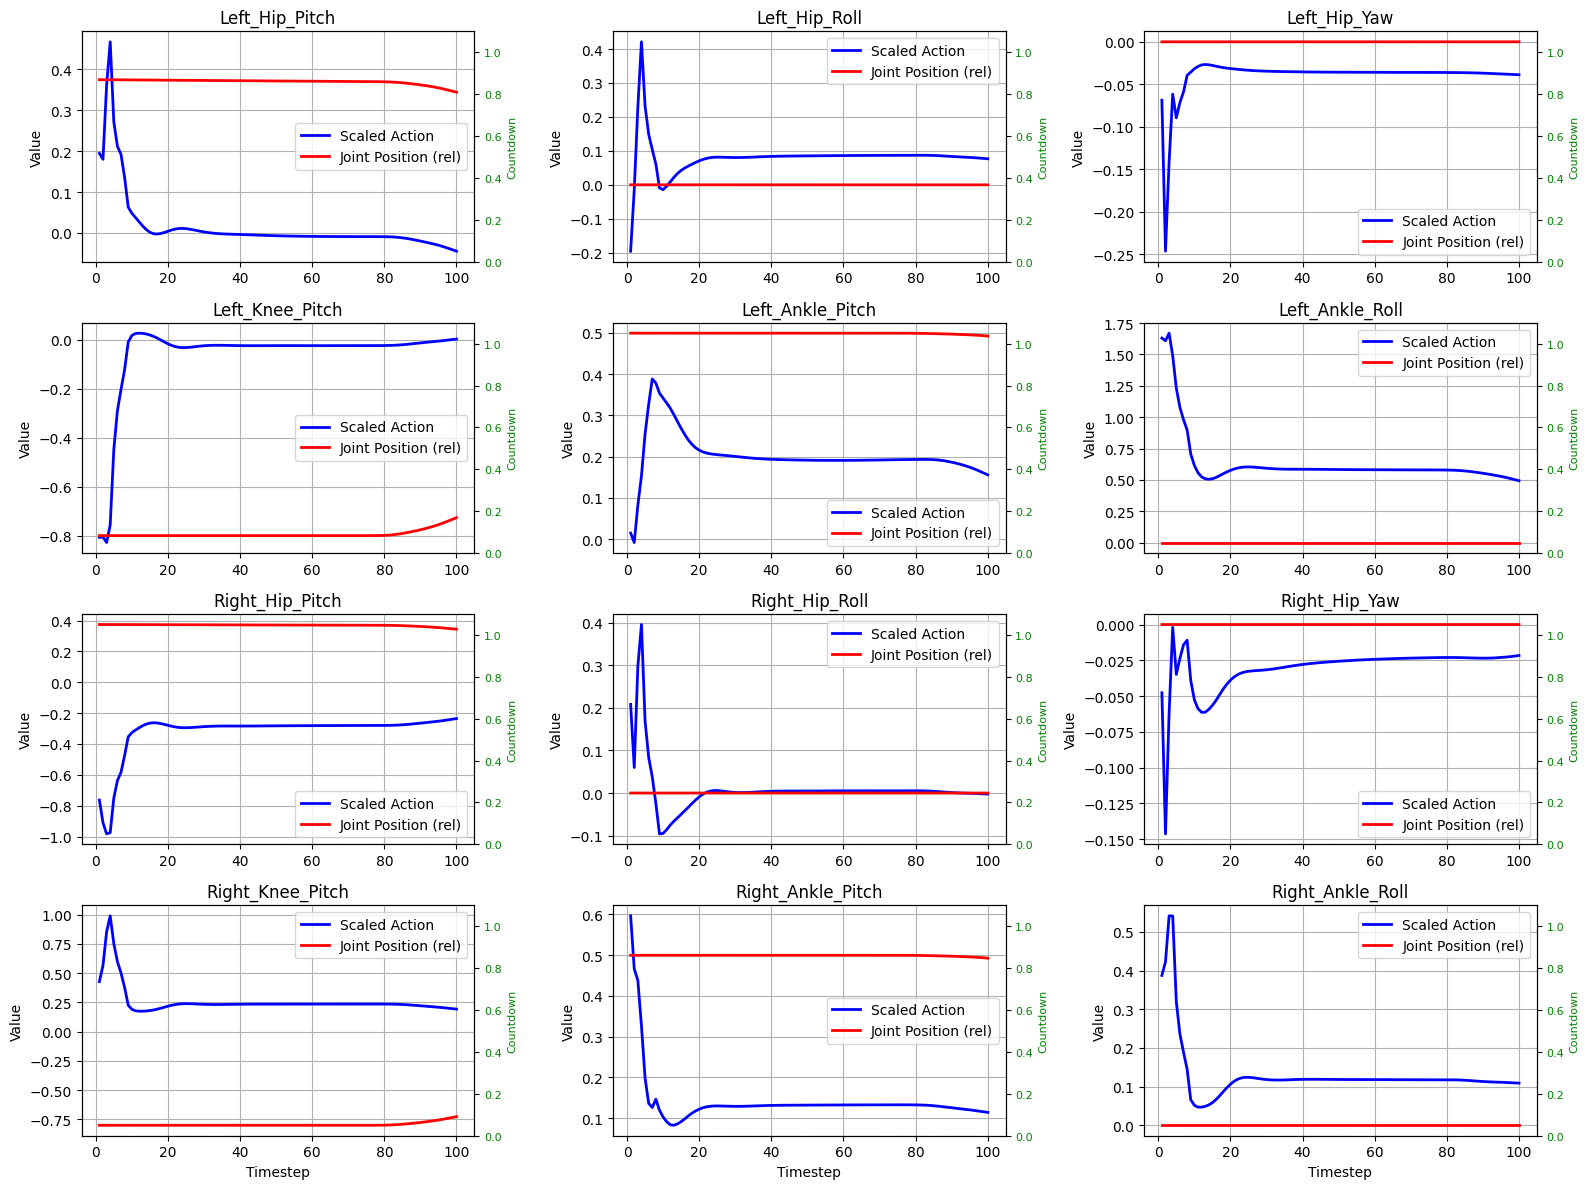

✓ Joint position vs scaled action comparison plot generated with countdown overlays!

Comparison Stats:
  Left_Hip_Pitch      : Action:  0.0150±0.0776 | Position:  0.3700±0.0062
  Left_Hip_Roll       : Action:  0.0807±0.0544 | Position: -0.0003±0.0000
  Left_Hip_Yaw        : Action: -0.0400±0.0248 | Position:  0.0000±0.0000
  Left_Knee_Pitch     : Action: -0.0587±0.1621 | Position: -0.7940±0.0155
  Left_Ankle_Pitch    : Action:  0.2027±0.0546 | Position:  0.4990±0.0014
  Left_Ankle_Roll     : Action:  0.6323±0.2230 | Position: -0.0000±0.0000
  Right_Hip_Pitch     : Action: -0.3176±0.1410 | Position:  0.3697±0.0062
  Right_Hip_Roll      : Action:  0.0088±0.0610 | Position:  0.0002±0.0000
  Right_Hip_Yaw       : Action: -0.0303±0.0159 | Position:  0.0000±0.0000
  Right_Knee_Pitch    : Action:  0.2576±0.1258 | Position: -0.7940±0.0156
  Right_Ankle_Pitch   : Action:  0.1399±0.0691 | Position:  0.4990±0.0014
  Right_Ankle_Roll    : Action:  0.1296±0.0784 | Position: -0.0000±0.0000


In [23]:
fig, axes = plt.subplots(4, 3, figsize=(16, 12))

timesteps = df_plot['timestep'].values

# DOF names in order
dof_names = [
    "Left_Hip_Pitch",
    "Left_Hip_Roll",
    "Left_Hip_Yaw",
    "Left_Knee_Pitch",
    "Left_Ankle_Pitch",
    "Left_Ankle_Roll",
    "Right_Hip_Pitch",
    "Right_Hip_Roll",
    "Right_Hip_Yaw",
    "Right_Knee_Pitch",
    "Right_Ankle_Pitch",
    "Right_Ankle_Roll",
]

for i in range(12):
    row = i // 3
    col = i % 3
    ax = axes[row, col]
    
    # Plot both scaled action and joint position on same axes
    ax.plot(timesteps, df_plot[f'scaled_action_{i}'], label='Scaled Action', linewidth=2, color='blue')
    ax.plot(timesteps, df_plot[f'joint_pos_rel_{i}'], label='Joint Position (rel)', linewidth=2, color='red')
    
    ax.set_ylabel('Value')
    ax.set_title(f'{dof_names[i]}')
    ax.legend(loc='best')
    ax.grid(True)
    
    # Add command countdown as overlay on secondary axis
    ax2 = ax.twinx()
    ax2.plot(timesteps, df_plot['command_countdown_0'], color='green', alpha=0.3, linewidth=1, linestyle='--', label='Countdown')
    ax2.set_ylabel('Countdown', color='green', fontsize=8)
    ax2.tick_params(axis='y', labelcolor='green', labelsize=8)
    ax2.set_ylim([0, 1.1])

axes[3, 0].set_xlabel('Timestep')
axes[3, 1].set_xlabel('Timestep')
axes[3, 2].set_xlabel('Timestep')

plt.tight_layout()
plt.show()

print("✓ Joint position vs scaled action comparison plot generated with countdown overlays!")
print(f"\nComparison Stats:")
for i in range(12):
    action_mean = df_plot[f'scaled_action_{i}'].mean()
    action_std = df_plot[f'scaled_action_{i}'].std()
    pos_mean = df_plot[f'joint_pos_rel_{i}'].mean()
    pos_std = df_plot[f'joint_pos_rel_{i}'].std()
    print(f"  {dof_names[i]:20s}: Action: {action_mean:7.4f}±{action_std:.4f} | Position: {pos_mean:7.4f}±{pos_std:.4f}")

## Plot 8: X and Y Positions vs Timestep - CoM and Feet

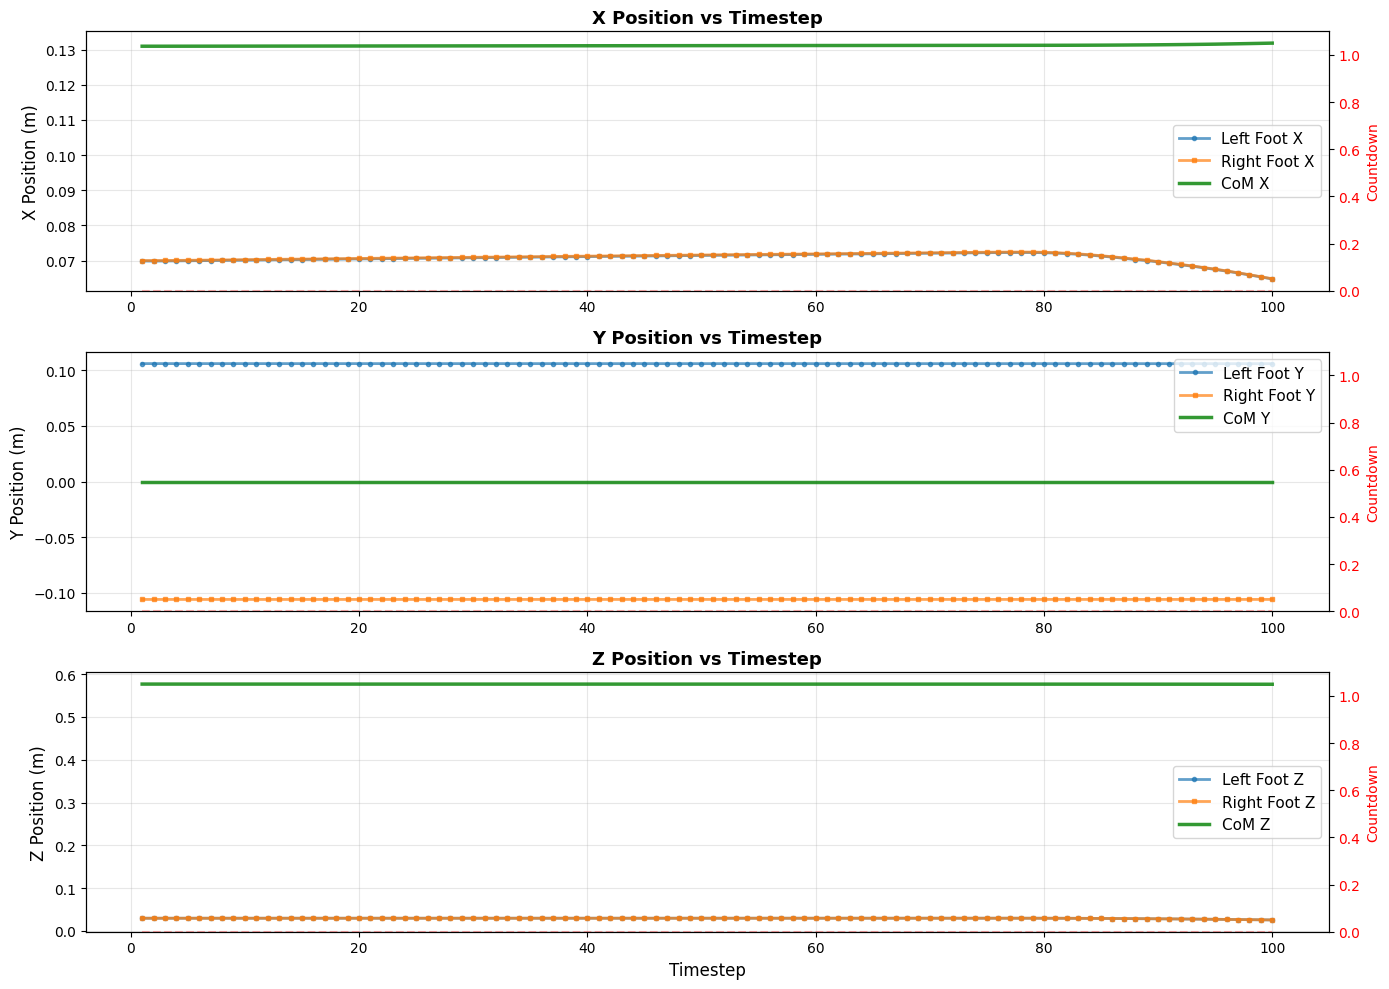

✓ X, Y and Z positions vs timestep plot generated with countdown overlays!

Position Change Stats:

Left Foot:
  X: 0.0699 → 0.0648 m (Δ -0.0051 m)
  Y: 0.1061 → 0.1061 m (Δ -0.0001 m)
  Z: 0.0297 → 0.0258 m (Δ -0.0040 m)

Right Foot:
  X: 0.0700 → 0.0648 m (Δ -0.0052 m)
  Y: -0.1062 → -0.1061 m (Δ 0.0000 m)
  Z: 0.0298 → 0.0258 m (Δ -0.0040 m)

Center of Mass:
  X: 0.1310 → 0.1319 m (Δ 0.0009 m)
  Y: -0.0002 → -0.0002 m (Δ -0.0000 m)
  Z: 0.5768 → 0.5764 m (Δ -0.0004 m)


In [24]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

timesteps = df_plot['timestep'].values

# X Position vs Timestep
ax = axes[0]
ax.plot(timesteps, df_plot['left_foot_xpos_x'], label='Left Foot X', linewidth=2, marker='o', markersize=3, alpha=0.7)
ax.plot(timesteps, df_plot['right_foot_xpos_x'], label='Right Foot X', linewidth=2, marker='s', markersize=3, alpha=0.7)
ax.plot(timesteps, df_plot['com_x'], label='CoM X', linewidth=2.5, color='green', alpha=0.8)
ax.set_ylabel('X Position (m)', fontsize=12)
ax.set_title('X Position vs Timestep', fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
# Add countdown overlay
ax2 = ax.twinx()
ax2.plot(timesteps, df_plot['command_countdown_0'], color='red', alpha=0.3, linewidth=1.5, linestyle='--', label='Countdown')
ax2.set_ylabel('Countdown', color='red', fontsize=10)
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim([0, 1.1])

# Y Position vs Timestep
ax = axes[1]
ax.plot(timesteps, df_plot['left_foot_xpos_y'], label='Left Foot Y', linewidth=2, marker='o', markersize=3, alpha=0.7)
ax.plot(timesteps, df_plot['right_foot_xpos_y'], label='Right Foot Y', linewidth=2, marker='s', markersize=3, alpha=0.7)
ax.plot(timesteps, df_plot['com_y'], label='CoM Y', linewidth=2.5, color='green', alpha=0.8)
ax.set_ylabel('Y Position (m)', fontsize=12)
ax.set_title('Y Position vs Timestep', fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
# Add countdown overlay
ax2 = ax.twinx()
ax2.plot(timesteps, df_plot['command_countdown_0'], color='red', alpha=0.3, linewidth=1.5, linestyle='--', label='Countdown')
ax2.set_ylabel('Countdown', color='red', fontsize=10)
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim([0, 1.1])

# Z Position vs Timestep
ax = axes[2]
ax.plot(timesteps, df_plot['left_foot_xpos_z'], label='Left Foot Z', linewidth=2, marker='o', markersize=3, alpha=0.7)
ax.plot(timesteps, df_plot['right_foot_xpos_z'], label='Right Foot Z', linewidth=2, marker='s', markersize=3, alpha=0.7)
ax.plot(timesteps, df_plot['com_z'], label='CoM Z', linewidth=2.5, color='green', alpha=0.8)
ax.set_ylabel('Z Position (m)', fontsize=12)
ax.set_xlabel('Timestep', fontsize=12)
ax.set_title('Z Position vs Timestep', fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
# Add countdown overlay
ax2 = ax.twinx()
ax2.plot(timesteps, df_plot['command_countdown_0'], color='red', alpha=0.3, linewidth=1.5, linestyle='--', label='Countdown')
ax2.set_ylabel('Countdown', color='red', fontsize=10)
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim([0, 1.1])

plt.tight_layout()
plt.show()

print("✓ X, Y and Z positions vs timestep plot generated with countdown overlays!")
print(f"\nPosition Change Stats:")
print(f"\nLeft Foot:")
print(f"  X: {df_plot['left_foot_xpos_x'].iloc[0]:.4f} → {df_plot['left_foot_xpos_x'].iloc[-1]:.4f} m (Δ {df_plot['left_foot_xpos_x'].iloc[-1] - df_plot['left_foot_xpos_x'].iloc[0]:.4f} m)")
print(f"  Y: {df_plot['left_foot_xpos_y'].iloc[0]:.4f} → {df_plot['left_foot_xpos_y'].iloc[-1]:.4f} m (Δ {df_plot['left_foot_xpos_y'].iloc[-1] - df_plot['left_foot_xpos_y'].iloc[0]:.4f} m)")
print(f"  Z: {df_plot['left_foot_xpos_z'].iloc[0]:.4f} → {df_plot['left_foot_xpos_z'].iloc[-1]:.4f} m (Δ {df_plot['left_foot_xpos_z'].iloc[-1] - df_plot['left_foot_xpos_z'].iloc[0]:.4f} m)")

print(f"\nRight Foot:")
print(f"  X: {df_plot['right_foot_xpos_x'].iloc[0]:.4f} → {df_plot['right_foot_xpos_x'].iloc[-1]:.4f} m (Δ {df_plot['right_foot_xpos_x'].iloc[-1] - df_plot['right_foot_xpos_x'].iloc[0]:.4f} m)")
print(f"  Y: {df_plot['right_foot_xpos_y'].iloc[0]:.4f} → {df_plot['right_foot_xpos_y'].iloc[-1]:.4f} m (Δ {df_plot['right_foot_xpos_y'].iloc[-1] - df_plot['right_foot_xpos_y'].iloc[0]:.4f} m)")
print(f"  Z: {df_plot['right_foot_xpos_z'].iloc[0]:.4f} → {df_plot['right_foot_xpos_z'].iloc[-1]:.4f} m (Δ {df_plot['right_foot_xpos_z'].iloc[-1] - df_plot['right_foot_xpos_z'].iloc[0]:.4f} m)")

print(f"\nCenter of Mass:")
print(f"  X: {df_plot['com_x'].iloc[0]:.4f} → {df_plot['com_x'].iloc[-1]:.4f} m (Δ {df_plot['com_x'].iloc[-1] - df_plot['com_x'].iloc[0]:.4f} m)")
print(f"  Y: {df_plot['com_y'].iloc[0]:.4f} → {df_plot['com_y'].iloc[-1]:.4f} m (Δ {df_plot['com_y'].iloc[-1] - df_plot['com_y'].iloc[0]:.4f} m)")
print(f"  Z: {df_plot['com_z'].iloc[0]:.4f} → {df_plot['com_z'].iloc[-1]:.4f} m (Δ {df_plot['com_z'].iloc[-1] - df_plot['com_z'].iloc[0]:.4f} m)")

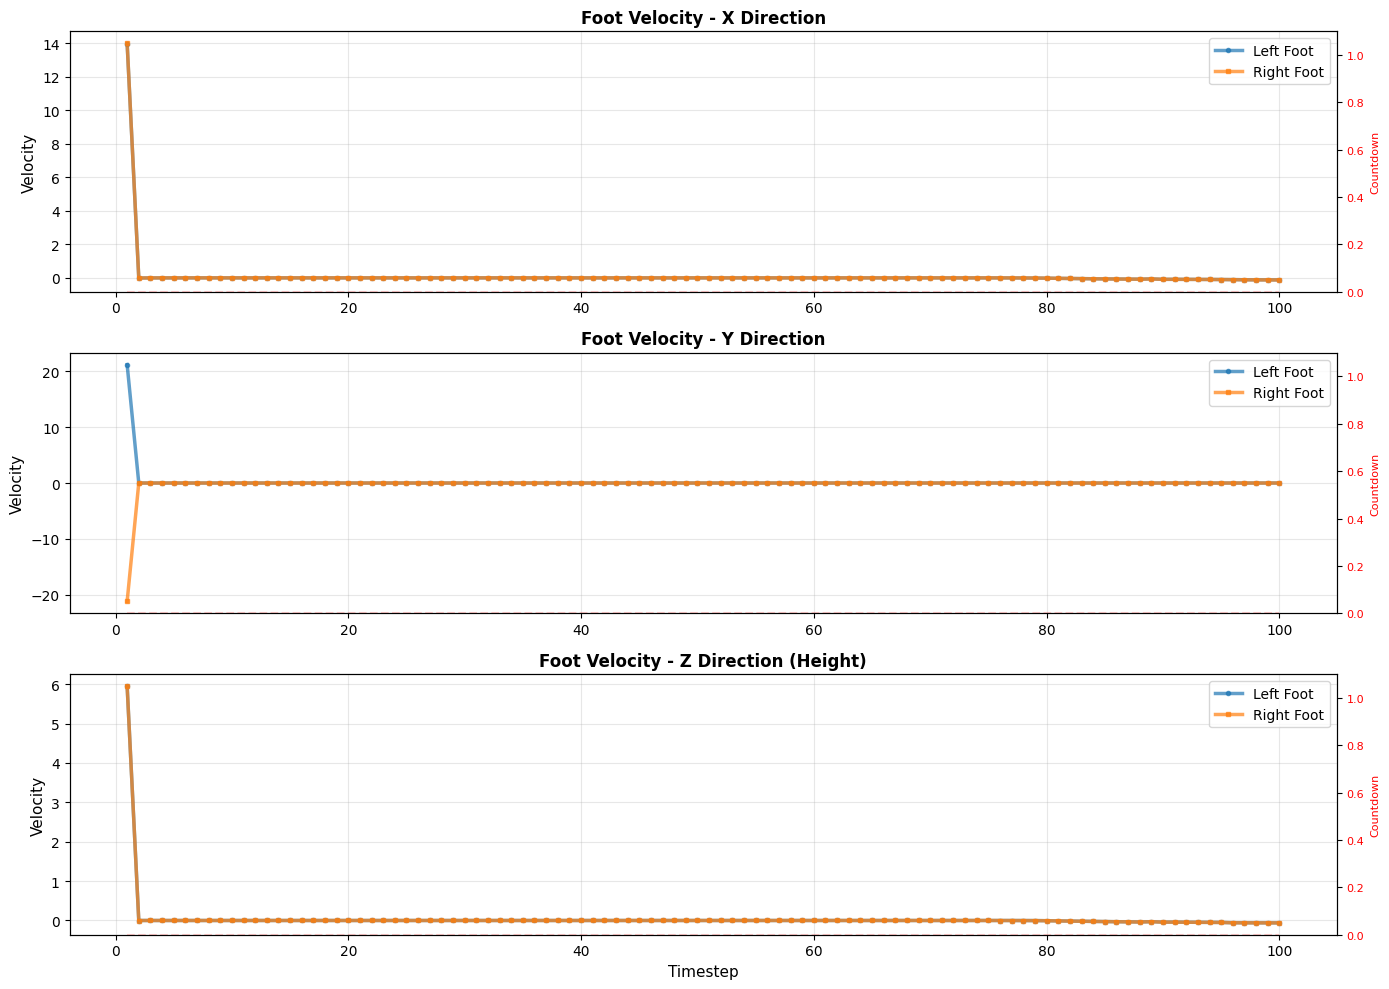

✓ Foot velocity plot generated!

Velocity Statistics (m/s):

X Direction:
  Left:   0.1295 ± 1.3986 m/s (max: 13.9717)
  Right:  0.1296 ± 1.4015 m/s (max: 14.0000)

Y Direction:
  Left:   0.2122 ± 2.1228 m/s (max: 21.2279)
  Right: -0.2123 ± 2.1232 m/s (max: 0.0000)

Z Direction (Height):
  Left:   0.0516 ± 0.5960 m/s (max: 5.9498)
  Right:  0.0516 ± 0.5961 m/s (max: 5.9502)


In [25]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

timesteps = df_plot['timestep'].values

# X Velocity
ax = axes[0]
ax.plot(timesteps, df_plot['left_foot_vel_x'], label='Left Foot', linewidth=2.5, marker='o', markersize=3, alpha=0.7)
ax.plot(timesteps, df_plot['right_foot_vel_x'], label='Right Foot', linewidth=2.5, marker='s', markersize=3, alpha=0.7)
ax.set_ylabel('Velocity', fontsize=11)
ax.set_title('Foot Velocity - X Direction', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
# Add countdown overlay
ax2 = ax.twinx()
ax2.plot(timesteps, df_plot['command_countdown_0'], color='red', alpha=0.2, linewidth=1.5, linestyle='--', label='Countdown')
ax2.set_ylabel('Countdown', color='red', fontsize=8)
ax2.tick_params(axis='y', labelcolor='red', labelsize=8)
ax2.set_ylim([0, 1.1])

# Y Velocity
ax = axes[1]
ax.plot(timesteps, df_plot['left_foot_vel_y'], label='Left Foot', linewidth=2.5, marker='o', markersize=3, alpha=0.7)
ax.plot(timesteps, df_plot['right_foot_vel_y'], label='Right Foot', linewidth=2.5, marker='s', markersize=3, alpha=0.7)
ax.set_ylabel('Velocity', fontsize=11)
ax.set_title('Foot Velocity - Y Direction', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
# Add countdown overlay
ax2 = ax.twinx()
ax2.plot(timesteps, df_plot['command_countdown_0'], color='red', alpha=0.2, linewidth=1.5, linestyle='--', label='Countdown')
ax2.set_ylabel('Countdown', color='red', fontsize=8)
ax2.tick_params(axis='y', labelcolor='red', labelsize=8)
ax2.set_ylim([0, 1.1])

# Z Velocity
ax = axes[2]
ax.plot(timesteps, df_plot['left_foot_vel_z'], label='Left Foot', linewidth=2.5, marker='o', markersize=3, alpha=0.7)
ax.plot(timesteps, df_plot['right_foot_vel_z'], label='Right Foot', linewidth=2.5, marker='s', markersize=3, alpha=0.7)
ax.set_ylabel('Velocity', fontsize=11)
ax.set_xlabel('Timestep', fontsize=11)
ax.set_title('Foot Velocity - Z Direction (Height)', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
# Add countdown overlay
ax2 = ax.twinx()
ax2.plot(timesteps, df_plot['command_countdown_0'], color='red', alpha=0.2, linewidth=1.5, linestyle='--', label='Countdown')
ax2.set_ylabel('Countdown', color='red', fontsize=8)
ax2.tick_params(axis='y', labelcolor='red', labelsize=8)
ax2.set_ylim([0, 1.1])

plt.tight_layout()
plt.show()

print("✓ Foot velocity plot generated!")
print(f"\nVelocity Statistics (m/s):")
print(f"\nX Direction:")
print(f"  Left:  {df_plot['left_foot_vel_x'].mean():7.4f} ± {df_plot['left_foot_vel_x'].std():.4f} m/s (max: {df_plot['left_foot_vel_x'].max():.4f})")
print(f"  Right: {df_plot['right_foot_vel_x'].mean():7.4f} ± {df_plot['right_foot_vel_x'].std():.4f} m/s (max: {df_plot['right_foot_vel_x'].max():.4f})")

print(f"\nY Direction:")
print(f"  Left:  {df_plot['left_foot_vel_y'].mean():7.4f} ± {df_plot['left_foot_vel_y'].std():.4f} m/s (max: {df_plot['left_foot_vel_y'].max():.4f})")
print(f"  Right: {df_plot['right_foot_vel_y'].mean():7.4f} ± {df_plot['right_foot_vel_y'].std():.4f} m/s (max: {df_plot['right_foot_vel_y'].max():.4f})")

print(f"\nZ Direction (Height):")
print(f"  Left:  {df_plot['left_foot_vel_z'].mean():7.4f} ± {df_plot['left_foot_vel_z'].std():.4f} m/s (max: {df_plot['left_foot_vel_z'].max():.4f})")
print(f"  Right: {df_plot['right_foot_vel_z'].mean():7.4f} ± {df_plot['right_foot_vel_z'].std():.4f} m/s (max: {df_plot['right_foot_vel_z'].max():.4f})")

## Plot 9: IMU Readings (Gyroscope and Accelerometer)

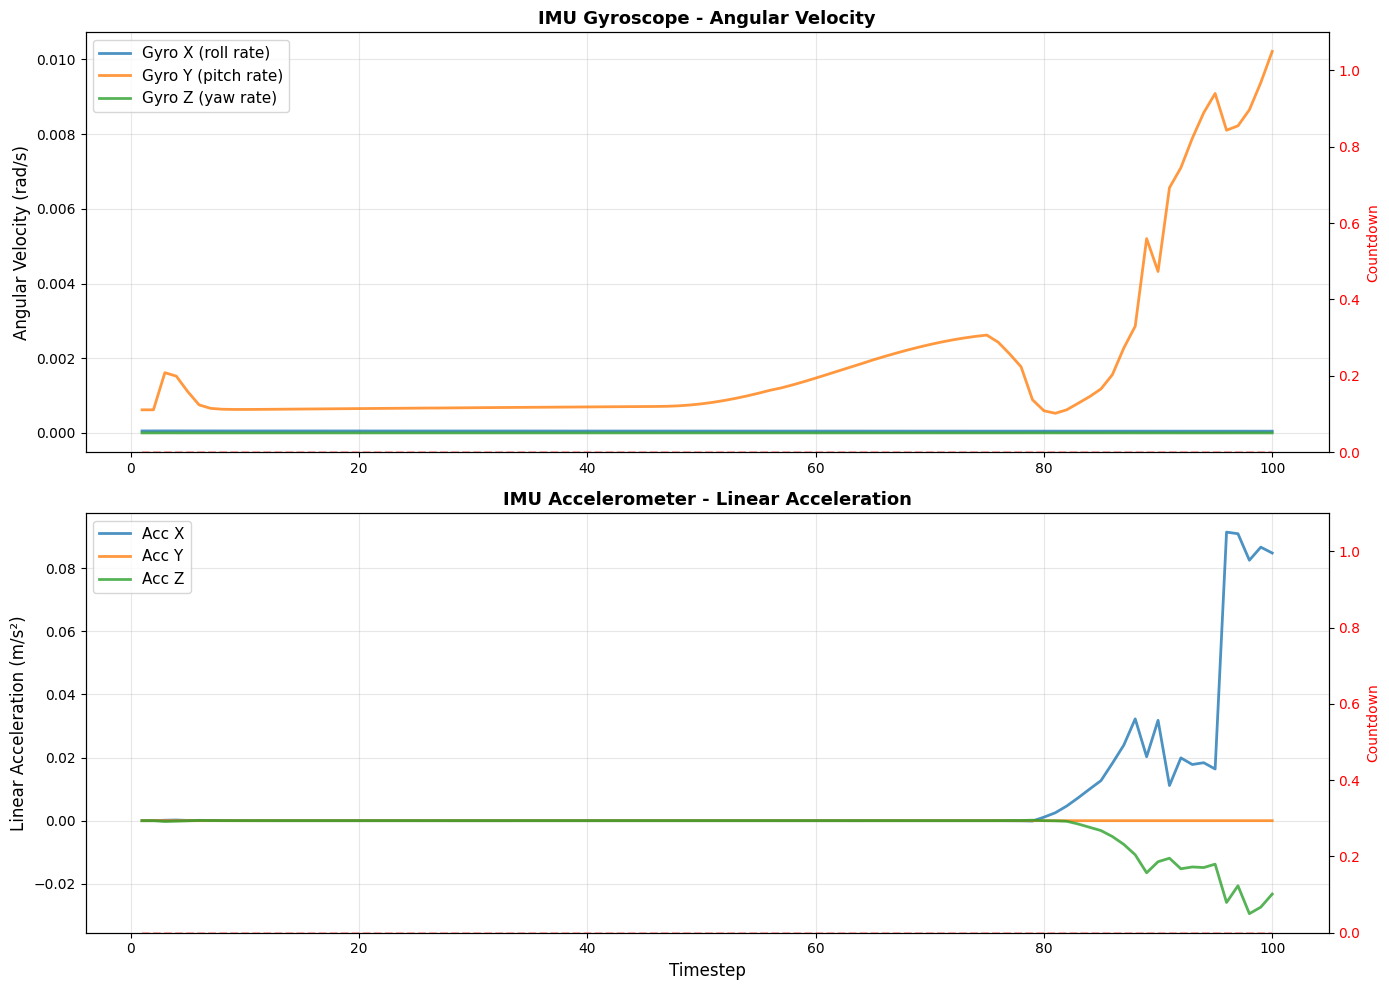

✓ IMU readings plot generated with countdown overlays!

IMU Statistics:

Gyroscope (Angular Velocity in rad/s):
  X (roll rate):   0.0000 ± 0.0000 rad/s (range: [0.0000, 0.0001])
  Y (pitch rate):  0.0019 ± 0.0023 rad/s (range: [0.0005, 0.0102])
  Z (yaw rate):    0.0000 ± 0.0000 rad/s (range: [-0.0000, 0.0000])

Accelerometer (Linear Acceleration in m/s²):
  X:  0.0069 ± 0.0197 m/s² (range: [-0.0001, 0.0914])
  Y:  0.0000 ± 0.0000 m/s² (range: [-0.0000, 0.0000])
  Z: -0.0026 ± 0.0066 m/s² (range: [-0.0295, 0.0001])

Magnitudes:
  Angular velocity magnitude: 0.0019 ± 0.0023 rad/s (max: 0.0102)
  Linear acceleration magnitude: 0.0074 ± 0.0208 m/s² (max: 0.0950)


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

timesteps = df_plot['timestep'].values

# Check if IMU data columns exist
imu_cols_exist = all(col in df_plot.columns for col in ['imu_gyro_x', 'imu_gyro_y', 'imu_gyro_z', 'imu_acc_x', 'imu_acc_y', 'imu_acc_z'])

if not imu_cols_exist:
    print("⚠️ WARNING: IMU data columns not found in the dataset.")
    print("Please ensure you're using a log file generated with the updated foot_track_plot.py script.")
    print("Expected columns: imu_gyro_x, imu_gyro_y, imu_gyro_z, imu_acc_x, imu_acc_y, imu_acc_z")
else:
    # Gyroscope (Angular Velocity)
    ax = axes[0]
    ax.plot(timesteps, df_plot['imu_gyro_x'], label='Gyro X (roll rate)', linewidth=2, alpha=0.8)
    ax.plot(timesteps, df_plot['imu_gyro_y'], label='Gyro Y (pitch rate)', linewidth=2, alpha=0.8)
    ax.plot(timesteps, df_plot['imu_gyro_z'], label='Gyro Z (yaw rate)', linewidth=2, alpha=0.8)
    ax.set_ylabel('Angular Velocity (rad/s)', fontsize=12)
    ax.set_title('IMU Gyroscope - Angular Velocity', fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=11)
    ax.grid(True, alpha=0.3)
    
    # Add countdown overlay
    ax2 = ax.twinx()
    ax2.plot(timesteps, df_plot['command_countdown_0'], color='red', alpha=0.3, linewidth=1.5, linestyle='--', label='Countdown')
    ax2.set_ylabel('Countdown', color='red', fontsize=10)
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.set_ylim([0, 1.1])
    
    # Accelerometer (Linear Acceleration)
    ax = axes[1]
    ax.plot(timesteps, df_plot['imu_acc_x'], label='Acc X', linewidth=2, alpha=0.8)
    ax.plot(timesteps, df_plot['imu_acc_y'], label='Acc Y', linewidth=2, alpha=0.8)
    ax.plot(timesteps, df_plot['imu_acc_z'], label='Acc Z', linewidth=2, alpha=0.8)
    ax.set_ylabel('Linear Acceleration (m/s²)', fontsize=12)
    ax.set_xlabel('Timestep', fontsize=12)
    ax.set_title('IMU Accelerometer - Linear Acceleration', fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=11)
    ax.grid(True, alpha=0.3)
    
    # Add countdown overlay
    ax2 = ax.twinx()
    ax2.plot(timesteps, df_plot['command_countdown_0'], color='red', alpha=0.3, linewidth=1.5, linestyle='--', label='Countdown')
    ax2.set_ylabel('Countdown', color='red', fontsize=10)
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.set_ylim([0, 1.1])
    
    plt.tight_layout()
    plt.show()
    
    print("✓ IMU readings plot generated with countdown overlays!")
    print(f"\nIMU Statistics:")
    print(f"\nGyroscope (Angular Velocity in rad/s):")
    print(f"  X (roll rate):  {df_plot['imu_gyro_x'].mean():7.4f} ± {df_plot['imu_gyro_x'].std():.4f} rad/s (range: [{df_plot['imu_gyro_x'].min():.4f}, {df_plot['imu_gyro_x'].max():.4f}])")
    print(f"  Y (pitch rate): {df_plot['imu_gyro_y'].mean():7.4f} ± {df_plot['imu_gyro_y'].std():.4f} rad/s (range: [{df_plot['imu_gyro_y'].min():.4f}, {df_plot['imu_gyro_y'].max():.4f}])")
    print(f"  Z (yaw rate):   {df_plot['imu_gyro_z'].mean():7.4f} ± {df_plot['imu_gyro_z'].std():.4f} rad/s (range: [{df_plot['imu_gyro_z'].min():.4f}, {df_plot['imu_gyro_z'].max():.4f}])")
    
    print(f"\nAccelerometer (Linear Acceleration in m/s²):")
    print(f"  X: {df_plot['imu_acc_x'].mean():7.4f} ± {df_plot['imu_acc_x'].std():.4f} m/s² (range: [{df_plot['imu_acc_x'].min():.4f}, {df_plot['imu_acc_x'].max():.4f}])")
    print(f"  Y: {df_plot['imu_acc_y'].mean():7.4f} ± {df_plot['imu_acc_y'].std():.4f} m/s² (range: [{df_plot['imu_acc_y'].min():.4f}, {df_plot['imu_acc_y'].max():.4f}])")
    print(f"  Z: {df_plot['imu_acc_z'].mean():7.4f} ± {df_plot['imu_acc_z'].std():.4f} m/s² (range: [{df_plot['imu_acc_z'].min():.4f}, {df_plot['imu_acc_z'].max():.4f}])")
    
    # Calculate magnitude of angular velocity and linear acceleration
    gyro_mag = np.sqrt(df_plot['imu_gyro_x']**2 + df_plot['imu_gyro_y']**2 + df_plot['imu_gyro_z']**2)
    acc_mag = np.sqrt(df_plot['imu_acc_x']**2 + df_plot['imu_acc_y']**2 + df_plot['imu_acc_z']**2)
    
    print(f"\nMagnitudes:")
    print(f"  Angular velocity magnitude: {gyro_mag.mean():.4f} ± {gyro_mag.std():.4f} rad/s (max: {gyro_mag.max():.4f})")
    print(f"  Linear acceleration magnitude: {acc_mag.mean():.4f} ± {acc_mag.std():.4f} m/s² (max: {acc_mag.max():.4f})")